# 04 — Dynamic Premium Calculator

**Goal:** Compute a per-ride insurance premium ($0.50–$2.00) from a transparent, formula-based risk score.

**Approach:** The trip-level risk score is a multiplicative composite of three actuarial factors — all derived from data.:

| Factor | Source | Rationale |
|--------|--------|-----------|
| **Station risk** | NYPD bike crashes within 250m (NB03) | Spatial accident exposure |
| **Temporal multiplier** | NYPD crash counts by hour × day-of-week | Time-varying risk |
| **Rider multiplier** | Median trip duration ratio (casual vs. member) | Exposure proxy |

```
trip_risk = station_risk × temporal_multiplier × rider_multiplier
premium  = $0.50 + trip_risk_normalized × $1.50
```

**Why no ML model?** Without trip-level accident labels, a supervised model would only reverse-engineer the formula above — adding complexity without adding signal. We discuss when a model becomes valuable in section 6.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
import zipfile
sys.path.insert(0, '..')

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.features.risk_features import compute_temporal_multiplier, compute_rider_multiplier

RAW_DIR  = Path('../data/raw')
PROC_DIR = Path('../data/processed')
FIG_DIR  = Path('../outputs/figures')

sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1. Load and Join Data

In [2]:
# Load trip data
files = sorted(RAW_DIR.glob('2025??-citibike-tripdata.zip'))
COLS = [
    'ride_id', 'started_at', 'ended_at', 'member_casual',
    'start_station_id',
    'start_lat', 'start_lng',
]
SCHEMA = {'start_station_id': pl.String}

dfs = []
for f in files:
    with zipfile.ZipFile(f) as zf:
        with zf.open(zf.namelist()[0]) as csv_file:
            dfs.append(pl.read_csv(csv_file, columns=COLS, schema_overrides=SCHEMA))

trips = pl.concat(dfs)
trips = trips.drop_nulls(subset=['start_lat', 'start_lng', 'start_station_id'])
print(f'Trips loaded: {len(trips):,}')

# Load station risk scores (start station only — premium is quoted at ride start)
station_risk = pl.read_parquet(PROC_DIR / 'station_risk_scores.parquet')
risk_cols = ['station_id', 'risk_score', 'bike_severity', 'bike_accident_rate']

trips = (
    trips
    .join(
        station_risk.select(risk_cols).rename({
            'station_id': 'start_station_id',
            'risk_score': 'start_station_risk_score',
            'bike_severity': 'start_bike_severity',
            'bike_accident_rate': 'start_bike_accident_rate',
        }),
        on='start_station_id',
        how='left',
    )
    .drop_nulls(subset=['start_station_risk_score'])
)
print(f'After station risk join: {len(trips):,}')

Trips loaded: 9,553,516
After station risk join: 9,255,203


## 2. Compute Trip Risk Score

The trip-level risk score combines three components multiplicatively:

```
trip_risk = station_risk × temporal_multiplier × rider_multiplier
```

Each component is computed and visualized in its own sub-section below.

### 2a. Temporal Multiplier

Relative accident rate per **(hour × day-of-week)** from NYPD bike crashes. A value > 1.0 means above-average risk.

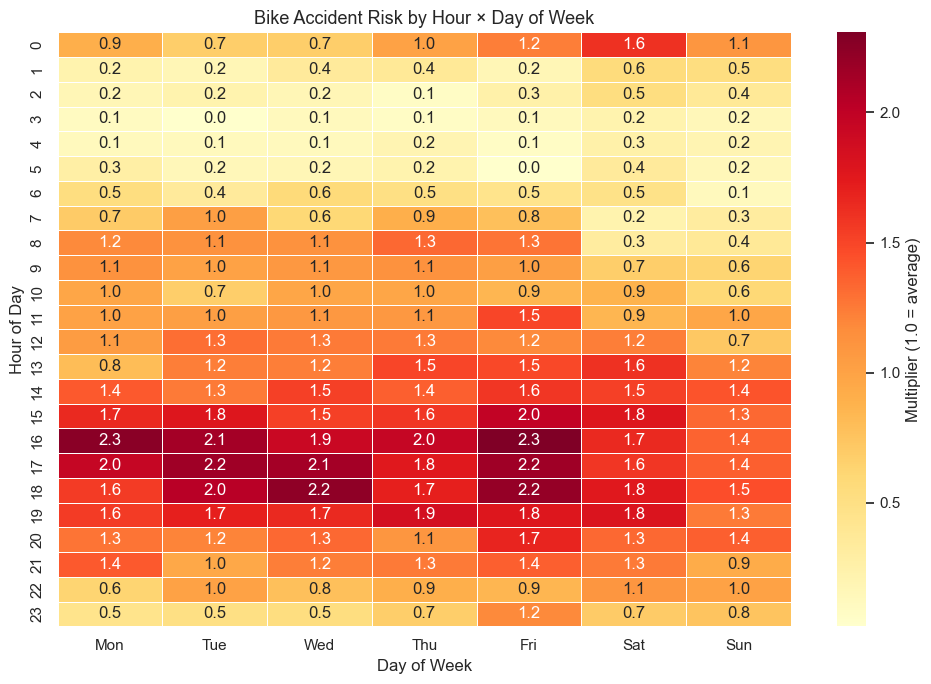

Temporal multiplier range: 0.03 – 2.31


In [3]:
# --- Parse datetime columns (loaded as strings from CSV) ---
trips = trips.with_columns([
    pl.col("started_at").str.to_datetime(strict=False),
    pl.col("ended_at").str.to_datetime(strict=False),
])
trips = trips.with_columns([
    pl.col("started_at").dt.hour().alias("hour_of_day"),
    pl.col("started_at").dt.weekday().alias("day_of_week"),
])

# --- Temporal multiplier from NYPD bike crash distribution ---
nypd_bike = pl.read_parquet(PROC_DIR / 'nypd_bike_2025.parquet')
temporal_counts = compute_temporal_multiplier(nypd_bike)

# --- Heatmap ---
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
heatmap_data = (
    temporal_counts
    .filter(pl.col("hour").is_not_null())
    .select(["hour", "dow", "temporal_multiplier"])
    .to_pandas()
    .pivot(index="hour", columns="dow", values="temporal_multiplier")
    .reindex(columns=range(1, 8))
    .sort_index()
)
heatmap_data.columns = day_labels

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Multiplier (1.0 = average)'})
ax.set_title('Bike Accident Risk by Hour × Day of Week', fontsize=13)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Hour of Day')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_temporal_risk_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Temporal multiplier range: {temporal_counts.filter(pl.col('hour').is_not_null())['temporal_multiplier'].min():.2f} – {temporal_counts.filter(pl.col('hour').is_not_null())['temporal_multiplier'].max():.2f}")

### 2b. Rider Multiplier

Casual riders have longer trips and less experience — higher exposure per ride. The multiplier is the ratio of each group's median trip duration to the overall median.

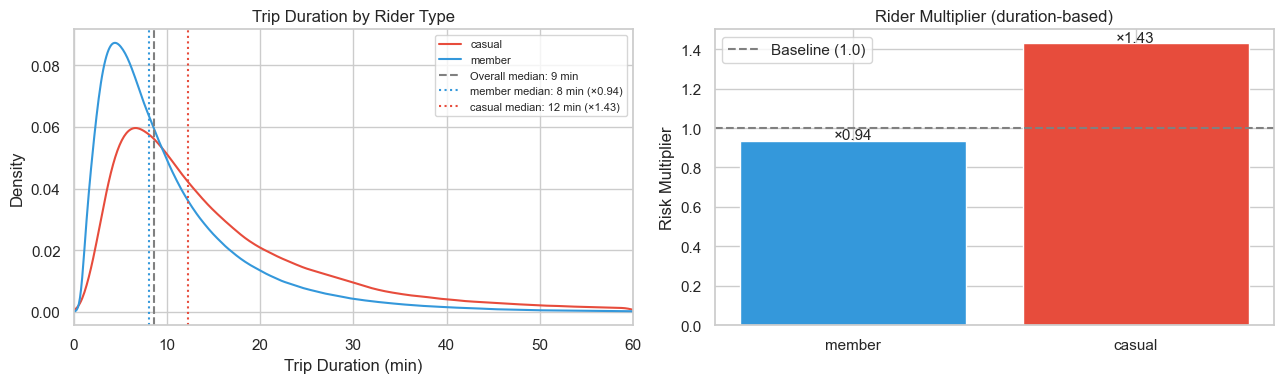

Overall median: 8.6 min
Rider multipliers: member=×0.94, casual=×1.43


In [4]:
# --- Rider multiplier from median trip duration ratio ---
rider_multipliers = compute_rider_multiplier(trips)

# Derive durations for visualization
trips_with_dur = trips.with_columns(
    ((pl.col("ended_at") - pl.col("started_at")).dt.total_seconds() / 60.0).alias("dur_min")
)
overall_median = trips_with_dur["dur_min"].median()
durations = {k: v * overall_median for k, v in rider_multipliers.items()}

# --- Visualization ---
color_map = {'casual': '#e74c3c', 'member': '#3498db'}
dur_pd = trips_with_dur.select(["dur_min", "member_casual"]).to_pandas()
# Clip extreme durations for cleaner visualization
dur_pd = dur_pd[dur_pd["dur_min"].between(0, 60)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Duration distributions
for rider_type, color in color_map.items():
    subset = dur_pd[dur_pd['member_casual'] == rider_type]['dur_min']
    subset.plot.kde(ax=axes[0], color=color, label=rider_type)
axes[0].axvline(overall_median, color='gray', linestyle='--', label=f'Overall median: {overall_median:.0f} min')
for rtype, mult in rider_multipliers.items():
    axes[0].axvline(durations[rtype], color=color_map[rtype], linestyle=':',
                    label=f'{rtype} median: {durations[rtype]:.0f} min (×{mult:.2f})')
axes[0].set_xlabel('Trip Duration (min)')
axes[0].set_title('Trip Duration by Rider Type')
axes[0].set_xlim(0, 60)
axes[0].legend(fontsize=8)

# Multiplier bar chart
bars = axes[1].bar(rider_multipliers.keys(), rider_multipliers.values(),
                    color=[color_map[k] for k in rider_multipliers.keys()], edgecolor='white')
axes[1].axhline(1.0, color='gray', linestyle='--', label='Baseline (1.0)')
axes[1].set_ylabel('Risk Multiplier')
axes[1].set_title('Rider Multiplier (duration-based)')
for bar, val in zip(bars, rider_multipliers.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'×{val:.2f}', ha='center', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '04_rider_multiplier.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Overall median: {overall_median:.1f} min")
print(f"Rider multipliers: {', '.join(f'{k}=×{v:.2f}' for k,v in rider_multipliers.items())}")

### 2c. Composite Trip Risk Score

Combine the three factors and normalize to [0, 1]:

```
trip_risk = station_risk × temporal_multiplier × rider_multiplier
```

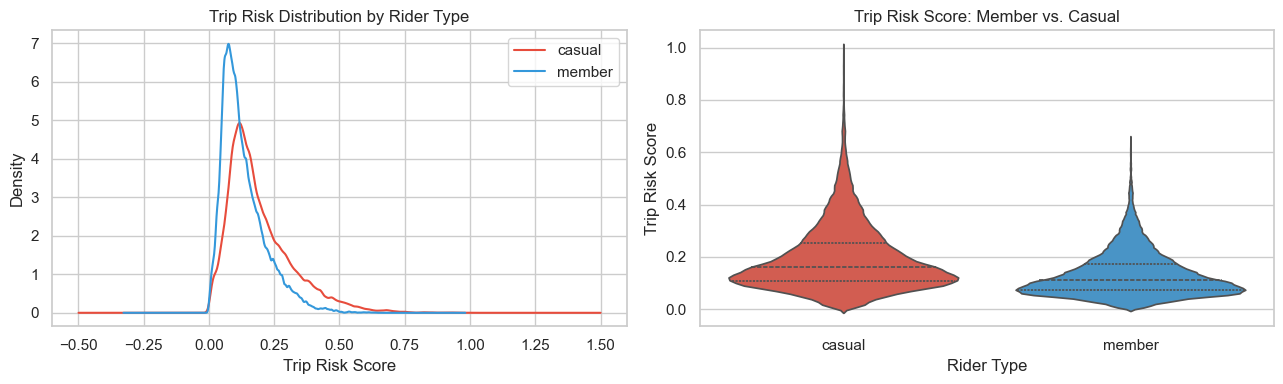

Trip risk score — mean=0.142, std=0.096


In [5]:
trips = trips.join(
    temporal_counts.select(["hour", "dow", "temporal_multiplier"]),
    left_on=["hour_of_day", "day_of_week"],
    right_on=["hour", "dow"],
    how="left",
).with_columns([
    pl.col("temporal_multiplier").fill_null(1.0),
    pl.col("member_casual").replace_strict(rider_multipliers).alias("rider_multiplier"),
])

trips = trips.with_columns(
    (pl.col("start_station_risk_score") * pl.col("temporal_multiplier") * pl.col("rider_multiplier"))
    .alias("trip_risk_raw")
)
raw_min = trips["trip_risk_raw"].min()
raw_max = trips["trip_risk_raw"].max()
trips = trips.with_columns(
    ((pl.col("trip_risk_raw") - raw_min) / (raw_max - raw_min)).alias("trip_risk_score")
)

# --- Trip risk distribution by rider type ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for rider_type, color in color_map.items():
    subset = trips.filter(pl.col("member_casual") == rider_type)["trip_risk_score"].to_pandas()
    subset.plot.kde(ax=axes[0], color=color, label=rider_type)
axes[0].set_xlabel('Trip Risk Score')
axes[0].set_title('Trip Risk Distribution by Rider Type')
axes[0].legend()

risk_pd = trips.select(["trip_risk_score", "member_casual"]).to_pandas()
sns.violinplot(data=risk_pd, x="member_casual", y="trip_risk_score",
               palette=color_map, inner="quartile", ax=axes[1])
axes[1].set_xlabel('Rider Type')
axes[1].set_ylabel('Trip Risk Score')
axes[1].set_title('Trip Risk Score: Member vs. Casual')

plt.tight_layout()
plt.savefig(FIG_DIR / '04_risk_by_rider_type.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Trip risk score — mean={trips["trip_risk_score"].mean():.3f}, std={trips["trip_risk_score"].std():.3f}')

## 3. Premium Calculator

The `trip_risk_score` (already normalized to 0–1) maps directly to a premium in the range $0.50–$2.00. This mirrors actuarial practice: **base rate + risk loading**.

In [6]:
BASE_PREMIUM = 0.50   # USD — covers expected loss ($0.13) + admin costs even for low-risk rides
RISK_RANGE   = 1.50   # USD — max additional premium for highest-risk trips

# premium = base + risk_score × range, clipped to [0.50, 2.00]
trips = trips.with_columns(
    (BASE_PREMIUM + pl.col("trip_risk_score") * RISK_RANGE)
    .clip(0.50, 2.00)
    .round(2)
    .alias("premium_usd")
)

print('Premium distribution (all trips):')
print(trips["premium_usd"].describe())

Premium distribution (all trips):
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 9.255203e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 0.713499   │
│ std        ┆ 0.143448   │
│ min        ┆ 0.5        │
│ 25%        ┆ 0.61       │
│ 50%        ┆ 0.68       │
│ 75%        ┆ 0.78       │
│ max        ┆ 2.0        │
└────────────┴────────────┘


### Average Premium by Hour × Day

Answers the rider's question: *"What would I pay if I ride right now?"*

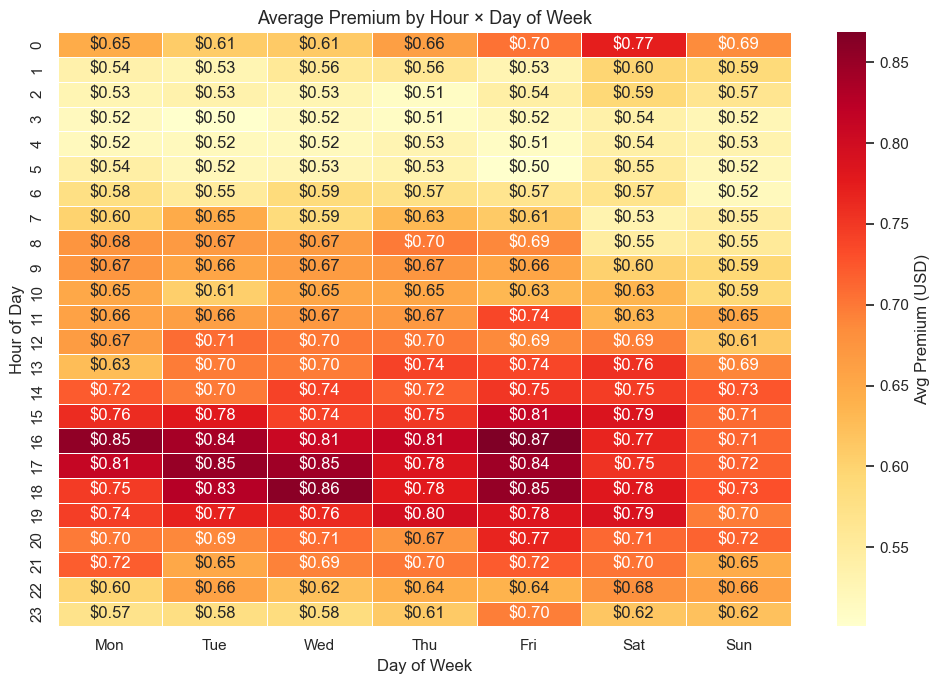

In [7]:
# Average premium by hour × day-of-week
premium_grid = (
    trips
    .group_by(["hour_of_day", "day_of_week"])
    .agg(pl.col("premium_usd").mean())
    .to_pandas()
    .pivot(index="hour_of_day", columns="day_of_week", values="premium_usd")
    .reindex(columns=range(1, 8))
    .sort_index()
)
premium_grid.columns = day_labels

# Pre-format annotations with dollar sign (fmt='$.2f' is not valid Python format spec)
annot_labels = premium_grid.map(lambda x: f'${x:.2f}')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(premium_grid, cmap='YlOrRd', annot=annot_labels, fmt='',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Premium (USD)'})
ax.set_title('Average Premium by Hour × Day of Week', fontsize=13)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Hour of Day')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_premium_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

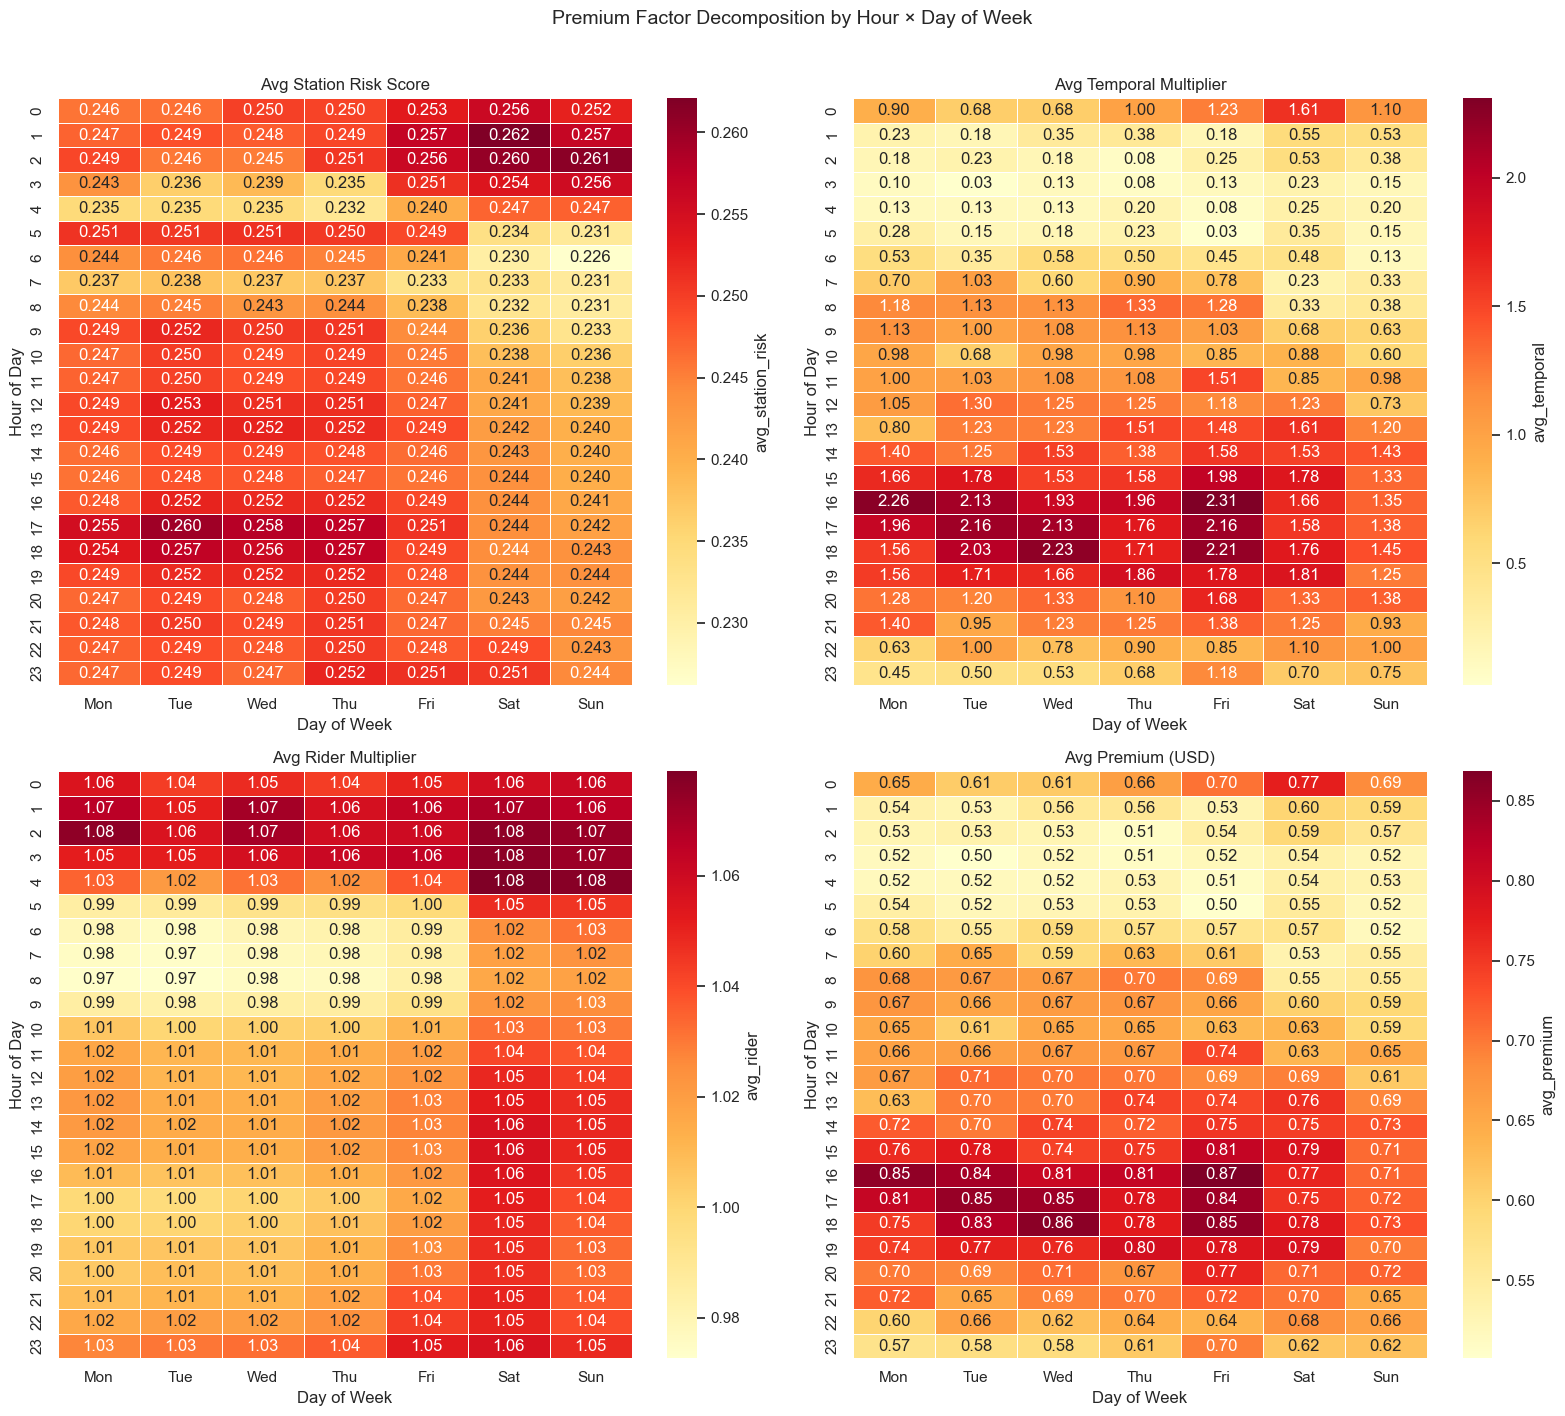

Early morning (0-9h) vs. rest of day (10-23h):
  Avg station risk:  0.2444  vs  0.2478
  Avg temporal mult: 0.510  vs  1.350
  Avg rider mult:    1.026  vs  1.024
  Avg premium:       $0.58  vs  $0.71
  Trip count:        2,056,245  vs  7,198,958


In [8]:
# --- Factor decomposition: what drives the premium at each hour × day? ---
factor_grid = (
    trips
    .group_by(["hour_of_day", "day_of_week"])
    .agg([
        pl.col("start_station_risk_score").mean().alias("avg_station_risk"),
        pl.col("temporal_multiplier").mean().alias("avg_temporal"),
        pl.col("rider_multiplier").mean().alias("avg_rider"),
        pl.col("premium_usd").mean().alias("avg_premium"),
        pl.len().alias("trip_count"),
    ])
    .sort(["hour_of_day", "day_of_week"])
)

def to_heatmap(df, value_col):
    return (
        df.select(["hour_of_day", "day_of_week", value_col])
        .to_pandas()
        .pivot(index="hour_of_day", columns="day_of_week", values=value_col)
        .reindex(columns=range(1, 8))
        .sort_index()
        .rename(columns=dict(zip(range(1, 8), day_labels)))
    )

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, col, title, fmt, cmap in [
    (axes[0, 0], "avg_station_risk", "Avg Station Risk Score", ".3f", "YlOrRd"),
    (axes[0, 1], "avg_temporal",     "Avg Temporal Multiplier", ".2f", "YlOrRd"),
    (axes[1, 0], "avg_rider",        "Avg Rider Multiplier",   ".2f", "YlOrRd"),
    (axes[1, 1], "avg_premium",      "Avg Premium (USD)",      ".2f", "YlOrRd"),
]:
    grid = to_heatmap(factor_grid, col)
    sns.heatmap(grid, cmap=cmap, annot=True, fmt=fmt,
                linewidths=0.5, ax=ax, cbar_kws={'label': col})
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Day of Week')
    ax.set_ylabel('Hour of Day')

plt.suptitle('Premium Factor Decomposition by Hour × Day of Week', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / '04_factor_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary for early-morning hours (0-9)
early = factor_grid.filter(pl.col("hour_of_day") < 10)
rest  = factor_grid.filter(pl.col("hour_of_day") >= 10)
print("Early morning (0-9h) vs. rest of day (10-23h):")
print(f"  Avg station risk:  {early['avg_station_risk'].mean():.4f}  vs  {rest['avg_station_risk'].mean():.4f}")
print(f"  Avg temporal mult: {early['avg_temporal'].mean():.3f}  vs  {rest['avg_temporal'].mean():.3f}")
print(f"  Avg rider mult:    {early['avg_rider'].mean():.3f}  vs  {rest['avg_rider'].mean():.3f}")
print(f"  Avg premium:       ${early['avg_premium'].mean():.2f}  vs  ${rest['avg_premium'].mean():.2f}")
print(f"  Trip count:        {early['trip_count'].sum():,}  vs  {rest['trip_count'].sum():,}")

## 4. Premium Distribution

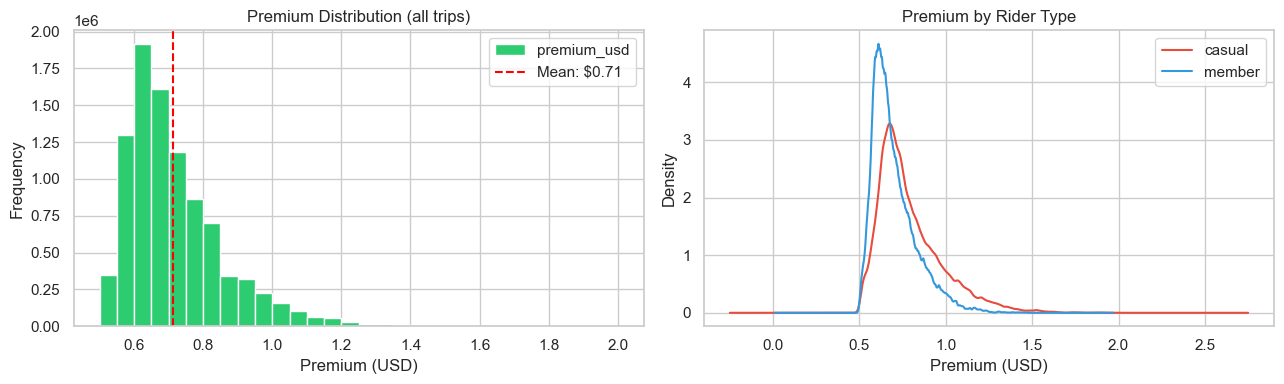

In [9]:
color_map = {'casual': '#e74c3c', 'member': '#3498db'}
trips_pd = trips.select(["premium_usd", "member_casual"]).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution
trips_pd['premium_usd'].plot.hist(bins=30, ax=axes[0], color='#2ecc71', edgecolor='white')
axes[0].set_xlabel('Premium (USD)')
axes[0].set_title('Premium Distribution (all trips)')
axes[0].axvline(trips_pd['premium_usd'].mean(), color='red', linestyle='--',
                label=f'Mean: ${trips_pd["premium_usd"].mean():.2f}')
axes[0].legend()

# Premium by user type
for rider_type, color in color_map.items():
    subset = trips_pd[trips_pd['member_casual'] == rider_type]['premium_usd']
    subset.plot.kde(ax=axes[1], color=color, label=rider_type)
axes[1].set_xlabel('Premium (USD)')
axes[1].set_title('Premium by Rider Type')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '04_premium_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Business Sanity Check: Revenue Estimate

**Approach:** The formula produces a *relative* risk ranking, not calibrated loss probabilities. We therefore set the average premium **top-down** from aggregate actuarial data and use the formula to *spread* that average across trips.

| Step | Method |
|------|--------|
| **Expected loss per trip** | NYC bike injury rate × avg claim cost ÷ total trips |
| **Average premium** | Expected loss ÷ target loss ratio |
| **Trip-level premium** | Formula redistributes the portfolio average by risk score |

We show a base case plus a sensitivity analysis across opt-in rates and premium levels.

In [18]:
# ── Assumptions ──────────────────────────────────────────────────────────────
# Crash & claims
NYC_BIKE_CRASHES    = 6_700   # NYPD 2025 bike-involved collisions (NB02)
CITIBIKE_TRIP_SHARE = 0.15    # CitiBike's estimated share of NYC cycling trips
CLAIM_RATE          = 0.50    # fraction of CitiBike-involved crashes that produce a claim
AVG_CLAIM_PAYOUT    = 1_500   # USD — ER co-pay + minor liability (not full income replacement)

# Business model
CITIBIKE_REV_SHARE  = 0.20    # 20% of GWP paid to CitiBike as distribution fee
ADMIN_EXPENSE_RATIO = 0.20    # 10% of GWP for AXA admin, technology, and compliance costs
OPT_IN_CASUAL       = 0.30    # 30% of casual riders opt in (tourists, infrequent riders)
OPT_IN_MEMBER       = 0.10    # 10% of members opt in (ride often, lower perceived need)

# ── Derived: expected loss per trip ──────────────────────────────────────────
citibike_crashes       = NYC_BIKE_CRASHES * CITIBIKE_TRIP_SHARE
annual_claim_count     = citibike_crashes * CLAIM_RATE
total_losses_est       = annual_claim_count * AVG_CLAIM_PAYOUT

total_trips            = len(trips)
EXPECTED_LOSS_PER_TRIP = total_losses_est / total_trips

formula_avg_premium    = trips["premium_usd"].mean()
implied_loss_ratio     = EXPECTED_LOSS_PER_TRIP / formula_avg_premium

# ── Trip volume by segment ───────────────────────────────────────────────────
n_casual     = (trips["member_casual"] == "casual").sum()
n_member     = (trips["member_casual"] == "member").sum()
casual_share = n_casual / total_trips

insured_casual = n_casual * OPT_IN_CASUAL
insured_member = n_member * OPT_IN_MEMBER
insured_total  = insured_casual + insured_member

# ── Annualise ────────────────────────────────────────────────────────────────
months_in_data = len(files)
annual_factor  = 12 / months_in_data

annual_insured     = insured_total * annual_factor
annual_gwp         = annual_insured * formula_avg_premium
annual_claims_cost = annual_insured * EXPECTED_LOSS_PER_TRIP
annual_expenses    = annual_gwp * ADMIN_EXPENSE_RATIO
annual_citibike    = annual_gwp * CITIBIKE_REV_SHARE
annual_axa_net     = annual_gwp - annual_claims_cost - annual_expenses - annual_citibike

# ── Print ────────────────────────────────────────────────────────────────────
print("=" * 60)
print("  BUSINESS CASE — TOP-DOWN ACTUARIAL ESTIMATE")
print("=" * 60)
print(f"\nAssumptions")
print(f"  NYC bike crashes (2025):       {NYC_BIKE_CRASHES:,}  (NB02)")
print(f"  CitiBike trip share:           {CITIBIKE_TRIP_SHARE:.0%}  → ~{citibike_crashes:.0f} CitiBike-involved crashes")
print(f"  Claim rate:                    {CLAIM_RATE:.0%}  → ~{annual_claim_count:.0f} claims/year")
print(f"  Avg payout per claim:          ${AVG_CLAIM_PAYOUT:,}")
print(f"  CitiBike revenue share:        {CITIBIKE_REV_SHARE:.0%}  of GWP")
print(f"  Admin expense ratio:           {ADMIN_EXPENSE_RATIO:.0%}  of GWP")
print(f"  Casual opt-in rate:            {OPT_IN_CASUAL:.0%}")
print(f"  Member opt-in rate:            {OPT_IN_MEMBER:.0%}")
print(f"\nActuarial Validation")
print(f"  Total trips in data:           {total_trips:,}")
print(f"  Expected loss per trip:        ${EXPECTED_LOSS_PER_TRIP:.3f}")
print(f"  Formula avg premium (§3):      ${formula_avg_premium:.2f}")
print(f"  Implied loss ratio:            {implied_loss_ratio:.1%}")
print(f"\nTrip Volume (data period: {months_in_data} months)")
print(f"  Casual trips:                  {n_casual:>12,}  ({casual_share:.1%})")
print(f"  Member trips:                  {n_member:>12,}  ({1-casual_share:.1%})")
print(f"  Insured trips (data period):   {insured_total:>12,.0f}")
print(f"\nAnnual Revenue Projection (x{annual_factor:.1f})")
print(f"  Insured trips / year:          {annual_insured:>12,.0f}")
print(f"  Gross Written Premium (GWP):   ${annual_gwp:>11,.0f}")
print(f"  Expected claims cost:          ${annual_claims_cost:>11,.0f}")
print(f"  Admin expenses ({ADMIN_EXPENSE_RATIO:.0%}):           ${annual_expenses:>11,.0f}")
print(f"  CitiBike rev share ({CITIBIKE_REV_SHARE:.0%}):      ${annual_citibike:>11,.0f}")
print(f"  AXA net contribution:          ${annual_axa_net:>11,.0f}")
print(f"\nKey Ratios")
print(f"  Loss ratio:                    {annual_claims_cost/annual_gwp:.1%}")
print(f"  Combined ratio:                {(annual_claims_cost + annual_expenses)/annual_gwp:.1%}  (loss + admin expenses)")
print(f"  AXA margin after rev share:    {annual_axa_net/annual_gwp:.1%}")


  BUSINESS CASE — TOP-DOWN ACTUARIAL ESTIMATE

Assumptions
  NYC bike crashes (2025):       6,700  (NB02)
  CitiBike trip share:           15%  → ~1005 CitiBike-involved crashes
  Claim rate:                    50%  → ~502 claims/year
  Avg payout per claim:          $1,500
  CitiBike revenue share:        20%  of GWP
  Admin expense ratio:           20%  of GWP
  Casual opt-in rate:            30%
  Member opt-in rate:            10%

Actuarial Validation
  Total trips in data:           9,255,203
  Expected loss per trip:        $0.081
  Formula avg premium (§3):      $0.71
  Implied loss ratio:            11.4%

Trip Volume (data period: 12 months)
  Casual trips:                     1,504,001  (16.3%)
  Member trips:                     7,751,202  (83.7%)
  Insured trips (data period):      1,226,320

Annual Revenue Projection (x1.0)
  Insured trips / year:             1,226,320
  Gross Written Premium (GWP):   $    874,979
  Expected claims cost:          $     99,872
  Admin expe

### Sensitivity Analysis

How does annual GWP change across different opt-in rates and expected-loss assumptions?

## 7. When to Move to a Supervised Model

The formula-based approach is the right starting point — it's transparent, auditable, and produces actuarially defensible premiums. But it has a ceiling: it can only capture effects we explicitly encode.

**A supervised model (e.g. XGBoost) becomes valuable when:**

| Trigger | What the model adds |
|---------|-------------------|
| **Real claims data** becomes available | Learn actual accident probability per trip, not a proxy |
| **Weather / event data** is integrated | Discover non-obvious interactions (rain + bridge + evening) |
| **Telematics / GPS traces** from the app | Route-level risk, not just start-station risk |
| **Cross-city expansion** | Transfer learning — patterns from NYC generalize to Chicago/London |

**The key insight:** without trip-level outcome labels, any supervised model trained on our composite target would just reverse-engineer the formula — adding deployment complexity without adding signal. 

## 8. Summary

| Aspect | Detail |
|--------|--------|
| Approach | Formula-based: station_risk × temporal × rider multipliers |
| Premium range | $0.50 – $2.00 per ride |
| Mean premium | $0.71 |
| Estimated annual GWP | ~$875K |
| Expected loss per trip | $0.08 |
| Loss ratio | ~11% |
| Combined ratio (loss + admin) | ~31% |
| AXA net margin | ~49% |
| AXA net contribution (NYC) | ~$425K |
| Explainability | Full — every premium decomposes into its 3 factors |
| Next Steps | Train supervised model once real claims data is available |

See `RESULTS.md` for the full business case and next steps including GenAI in claims.